# **CREDIT RISK MODELLING**

---



---

##**INTRODUCTION**

---



---

Credit risk modelling refers to estimating the risk associated with lending credit to a borrower.
 If the lender fails to detect the credit risk in advance, it exposes them to the risk of default and loss of funds, thats why Lenders rely on the validation provided by credit risk analysis models to make key lending decisions on whether or not to extend credit to the borrower and the credit to be charged.

The probability of default, sometimes abbreviated as POD, is the likelihood that a borrower will default on their loan obligations.

#### **Project Overview**

In this project, different learning algorithms including KNN, Logistic regression, decision tree, and random forest have been used to find the best algorithm for credit risk . SMOTE has been used for handling the imbalanced data. KNN Imputer is used for imputing the missing values.

#### **Dataset and features**

The dataset for this credit risk modelling project has been taken from kaggle.The dataset classifies the credit risk of borrower with respect to various features such as Age , Income , Employment length , Home ownership and other attributes of loan such as Interest Rate , Purpose etc.

**Importing Libraries**

In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn import model_selection
import warnings
warnings.filterwarnings('ignore')

**Loading the dataset**

In [ ]:
df_loan = pd.read_csv('credit_risk_dataset.csv')

In [ ]:
df_loan.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print('The shape of our data is:', df_loan.shape)

The shape of our data is: (32581, 12)


## **DATA PREPROCESSING**

---



---



Using pandas for data cleaning and data manipulation

### Duplicate rows

In [ ]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
# Checking Duplicates
duplicate = df_loan[df_loan.duplicated()]
duplicate.shape[0]


165

In [ ]:
df_loan.drop_duplicates(inplace= True)

print('The shape of the data after removal of duplicate rows is:', df_loan.shape)

The shape of the data after removal of duplicate rows is: (32416, 12)


###**Exploratory Data Analysis**

---



####**Numerical Features**

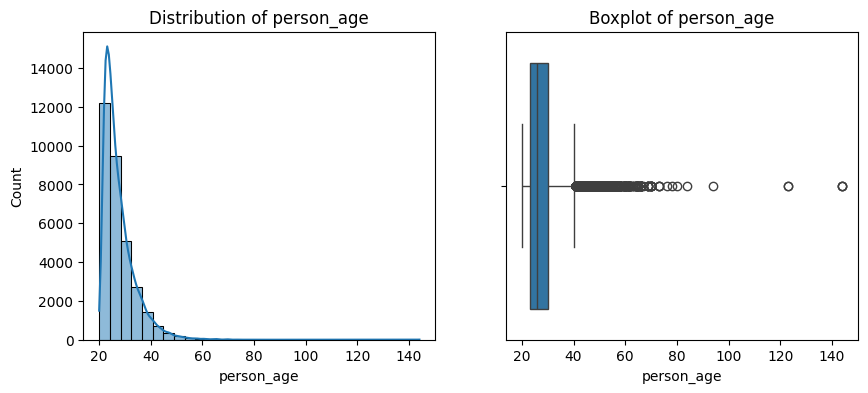

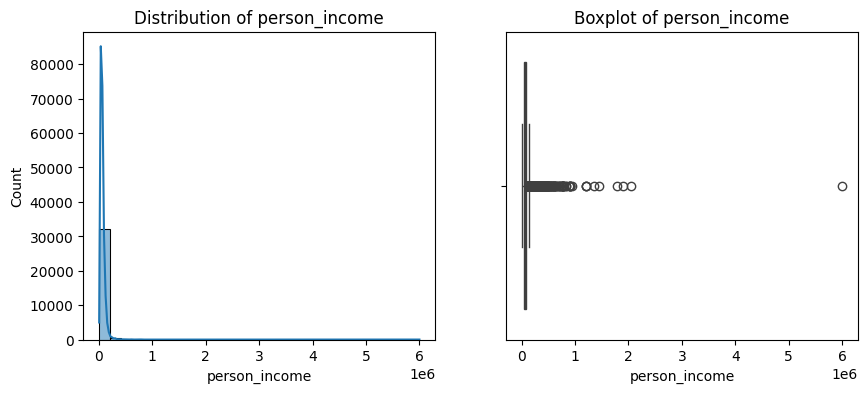

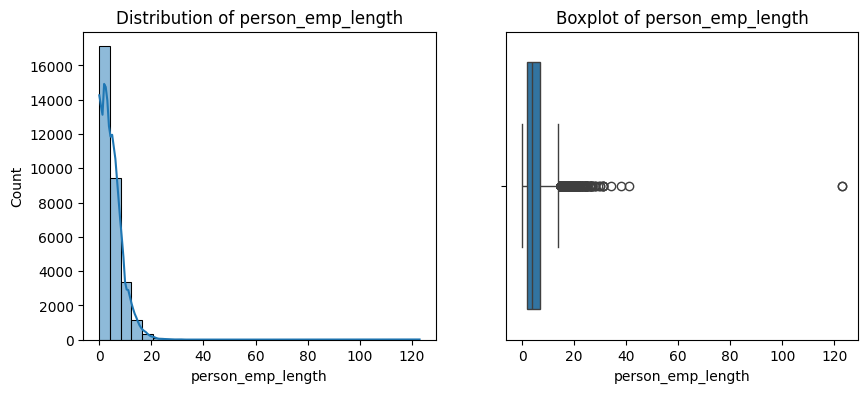

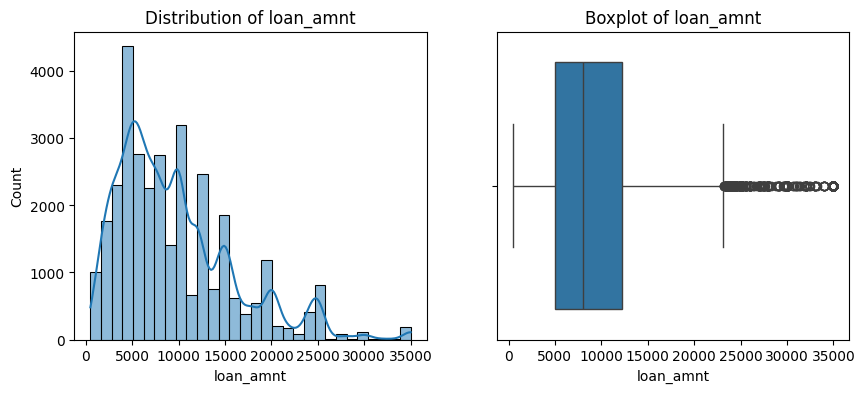

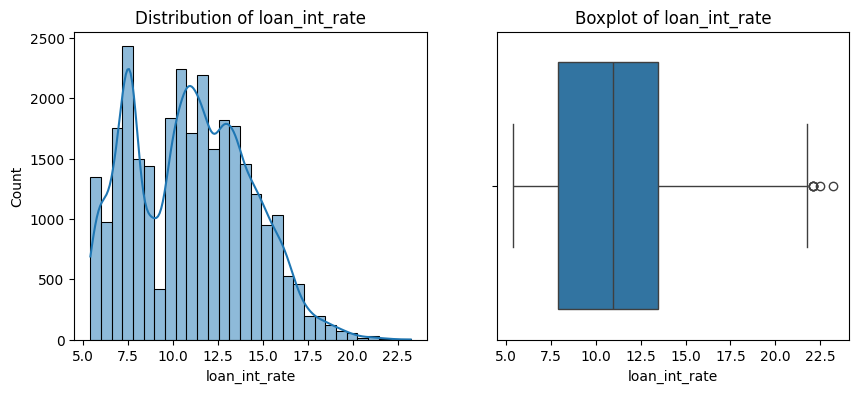

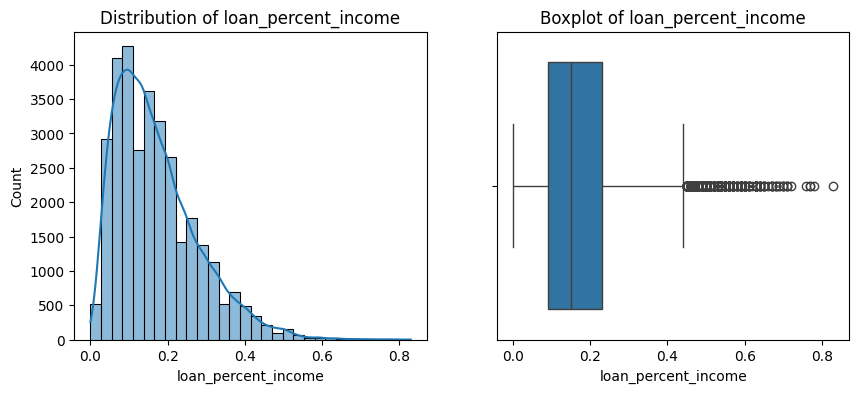

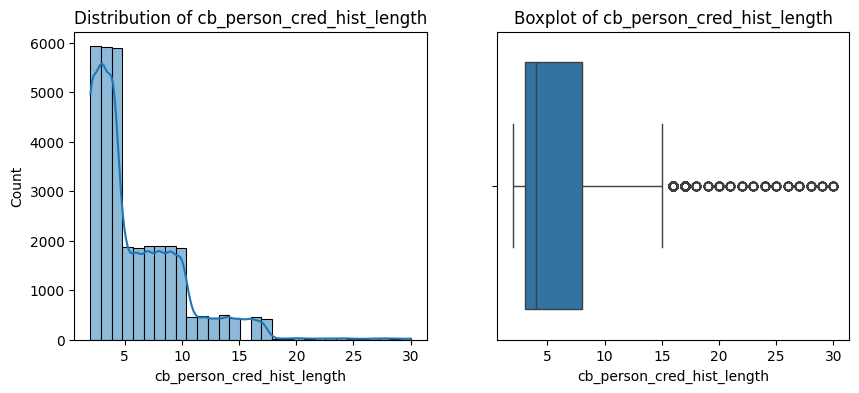

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

for col in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df_loan[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df_loan[col])
    plt.title(f'Boxplot of {col}')

    plt.show()


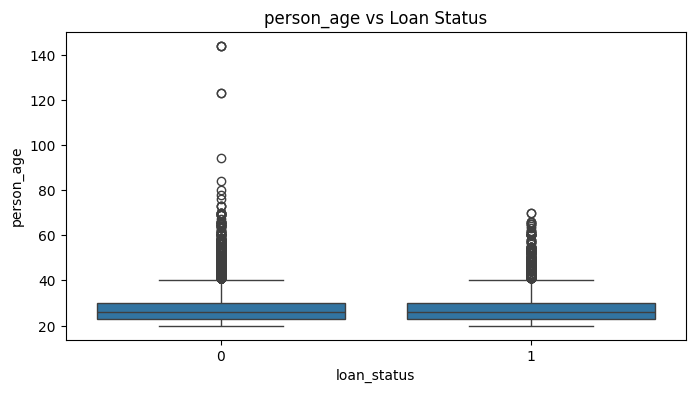

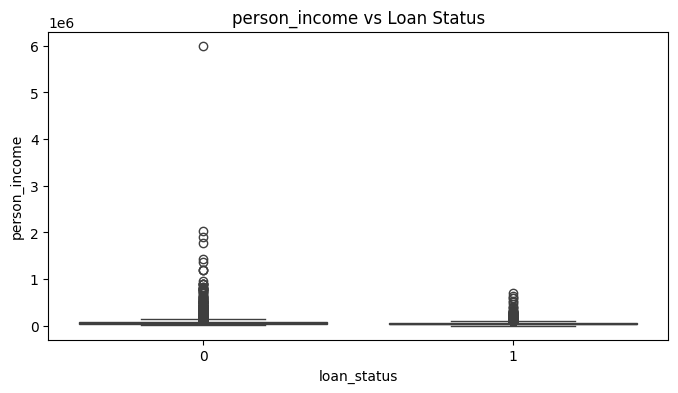

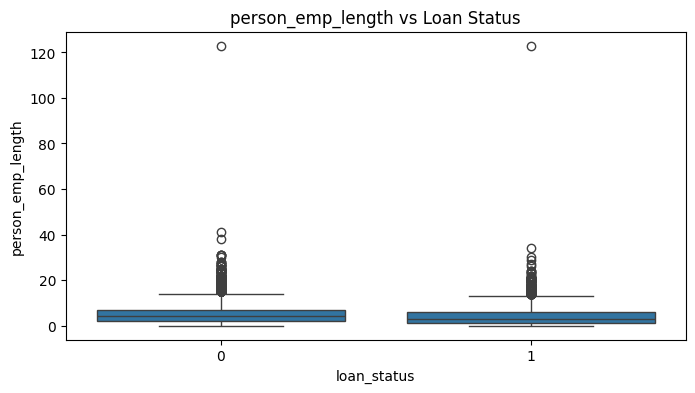

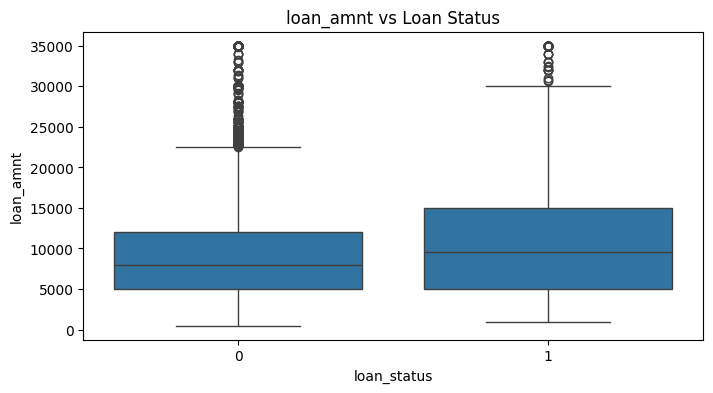

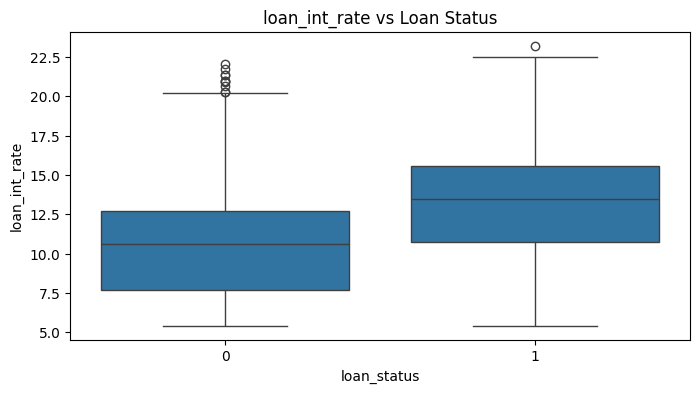

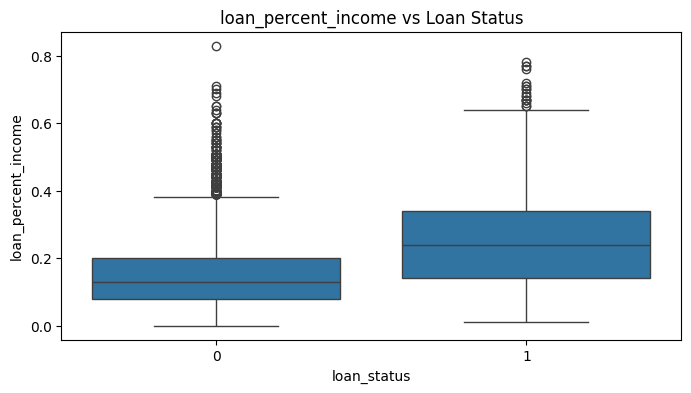

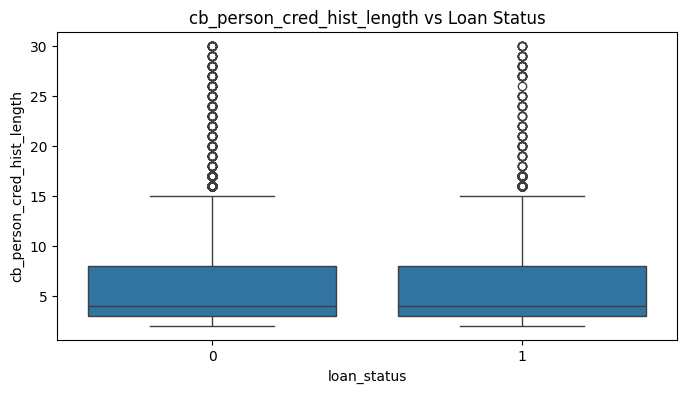

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='loan_status', y=col, data=df_loan)
    plt.title(f"{col} vs Loan Status")
    plt.show()

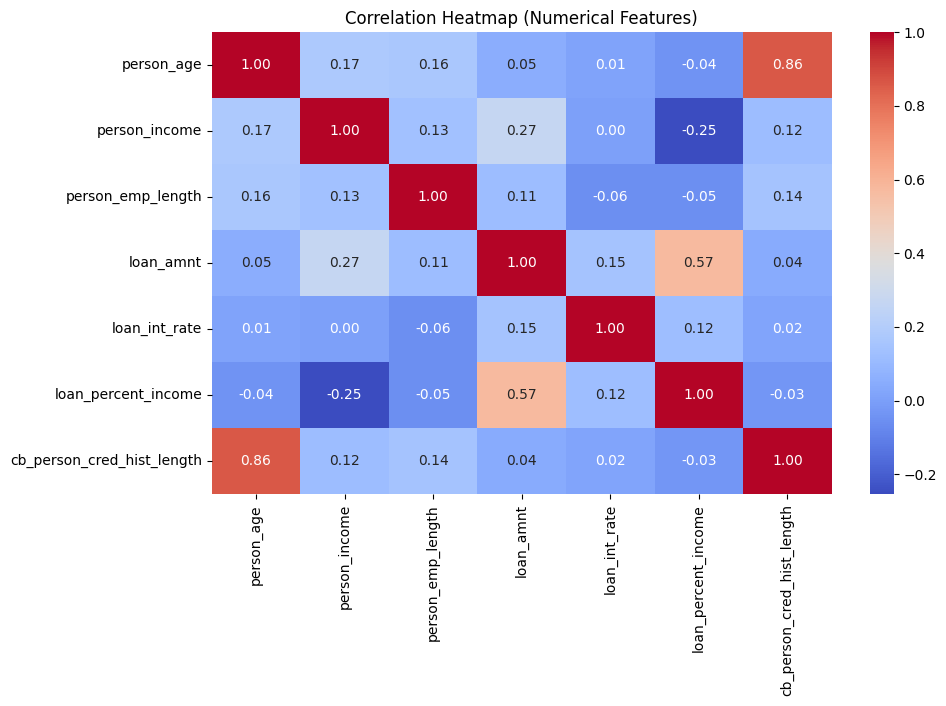

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_loan[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


####**Categorical Features**



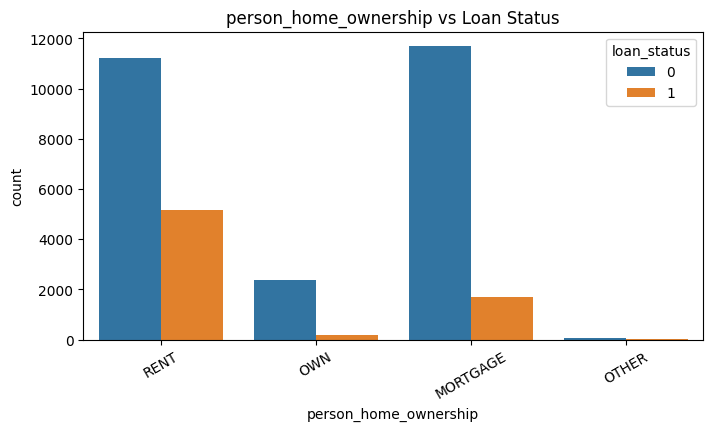

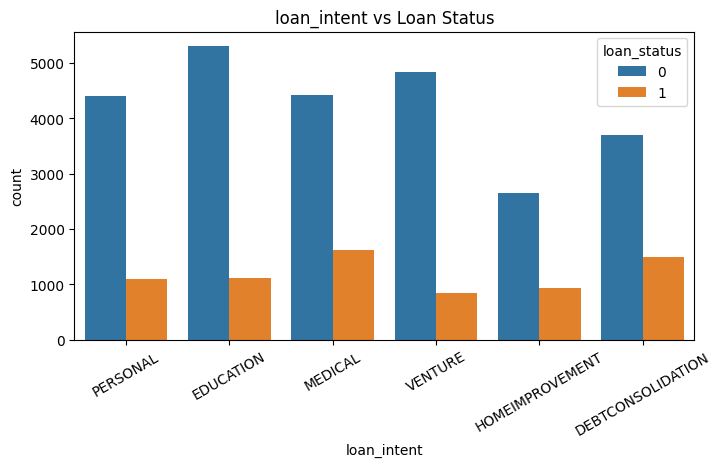

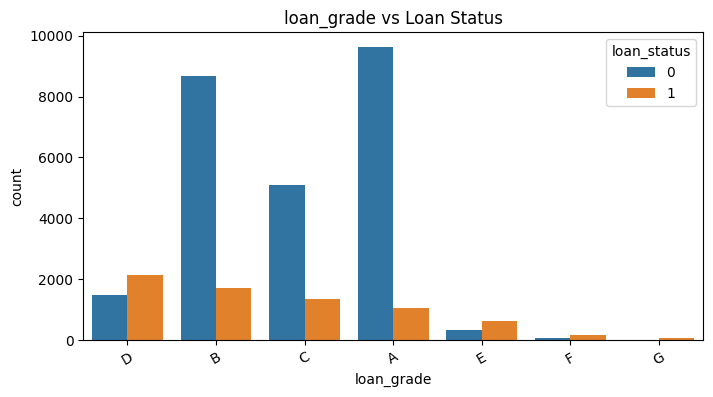

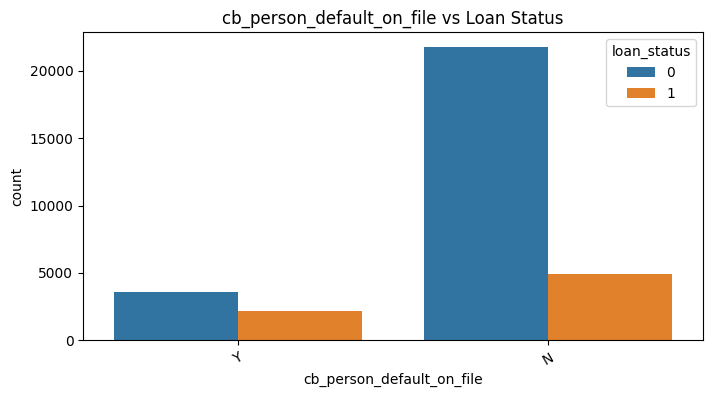

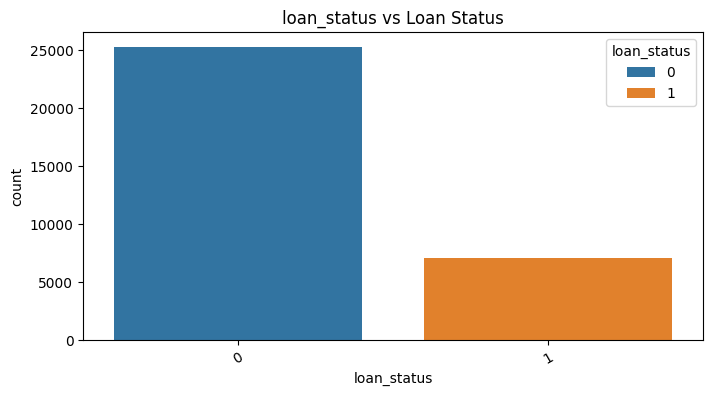

In [ ]:
cat_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file','loan_status']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df_loan, x=col, hue='loan_status')  # compare with loan_status
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=30)
    plt.show()


### Handeling Outliers

In [ ]:
(df_loan['loan_status'].value_counts(normalize=True) * 100).reset_index()


,loan_status,proportion
0,0,78.13117
1,1,21.86883


In [ ]:
Q1 = df_loan[num_cols].quantile(0.25)
Q3 = df_loan[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_loan[num_cols] < (Q1 - 1.5*IQR)) | (df_loan[num_cols] > (Q3 + 1.5*IQR))).sum()
print(outliers)


person_age                    1491
person_income                 1478
person_emp_length              852
loan_amnt                     1679
loan_int_rate                    6
loan_percent_income            650
cb_person_cred_hist_length    1139
dtype: int64


In [ ]:
#calculate the skewness of each numerical column.
df_loan[num_cols].skew().sort_values()


,0
loan_int_rate,0.207002
loan_percent_income,1.063811
loan_amnt,1.191944
cb_person_cred_hist_length,1.659369
person_age,2.580490
person_emp_length,2.619915
person_income,32.958748


From the skewness analysis, I observed that most of the numerical variables are positively skewed. loan_int_rate is almost symmetric with a skewness of around 0.21, while loan_percent_income and loan_amnt show moderate right skewness. cb_person_cred_hist_length, person_age, and person_emp_length are more strongly right-skewed. The most noticeable feature is person_income, with a skewness of around 33, indicating an extremely right-skewed distribution and the possible presence of extreme income values

### Feature Engineering

In [ ]:
df_loan['debt_to_income'] = df_loan['loan_amnt'] / df_loan['person_income']
df_loan['age_group'] = pd.cut(df_loan['person_age'], bins=[18, 25, 35, 50, 100],
                         labels=['Young', 'Mid_Age', 'Adult', 'Senior'])
df_loan['emp_length_cat'] = pd.cut(df_loan['person_emp_length'],
                              bins=[0, 2, 5, 10, 50],
                              labels=['Short', 'Medium', 'Long', 'Very_Long'])


In [ ]:
df_loan.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,debt_to_income,age_group,emp_length_cat
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.593220,Young,NaN
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,Young,Medium
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,Young,Short
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,Young,Medium
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,Young,Long


**<h1>Train-Test_Split</h1>**

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_loan.drop('loan_status', axis=1)
y = df_loan['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Reset indices so X and y are perfectly aligned
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,debt_to_income,age_group,emp_length_cat
0,23,75800,RENT,0.0,PERSONAL,A,7000,6.54,0.09,N,2,0.092348,Young,NaN
1,25,61959,RENT,9.0,EDUCATION,C,25000,12.73,0.40,Y,4,0.403493,Young,Long
2,31,53088,RENT,0.0,PERSONAL,A,6000,6.54,0.11,N,9,0.113020,Mid_Age,NaN
3,27,228000,MORTGAGE,12.0,HOMEIMPROVEMENT,A,6000,7.14,0.03,N,6,0.026316,Mid_Age,Very_Long
4,29,54000,RENT,0.0,PERSONAL,D,10000,14.96,0.19,N,9,0.185185,Mid_Age,NaN


**<h1>Handling Outliers</h1>**

In [ ]:
X_train.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,debt_to_income
count,25932.000000,2.593200e+04,25205.000000,25932.000000,23444.000000,25932.000000,25932.000000,25932.000000
mean,27.726207,6.582851e+04,4.769411,9592.168942,11.022012,0.170757,5.798164,0.171110
std,6.358676,6.309301e+04,4.149885,6286.927457,3.233923,0.106776,4.045591,0.107071
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000833
25%,23.000000,3.840000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000,0.090179
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000,0.148810
75%,30.000000,7.864375e+04,7.000000,12250.000000,13.480000,0.230000,8.000000,0.230769
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,0.830000


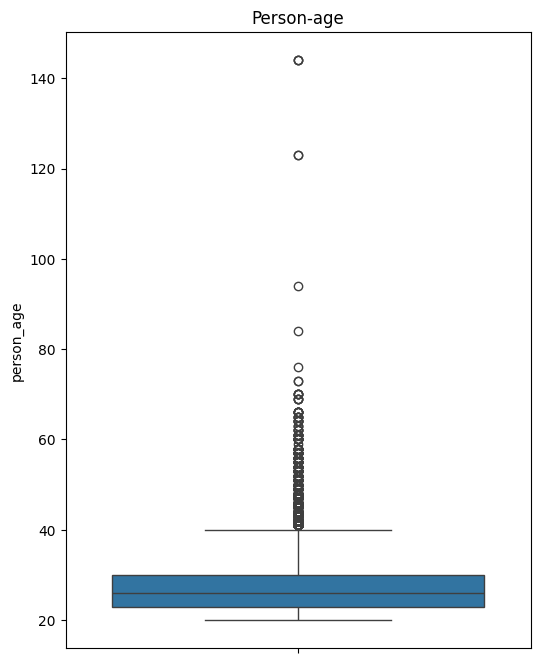

In [ ]:
# Outliers in the age column

plt.figure(figsize=(6,8))
sns.boxplot(y='person_age', data=X_train)
plt.title('Person-age');

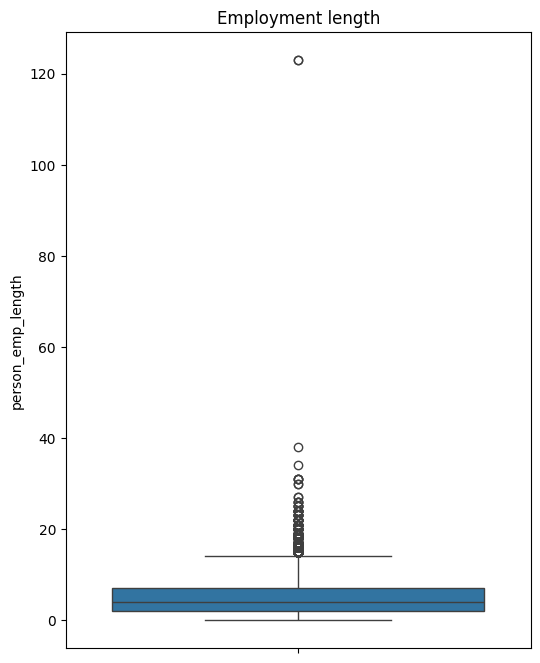

In [ ]:
#Outliers in Employment Length Column

plt.figure(figsize=(6,8))
sns.boxplot(y='person_emp_length', data=X_train)
plt.title('Employment length');

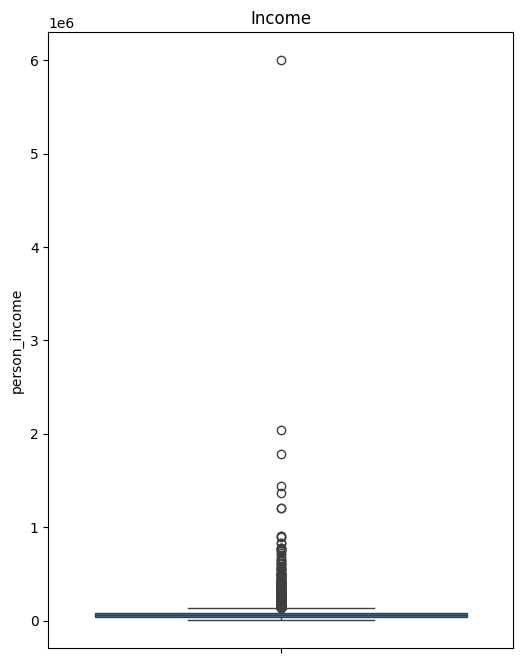

In [ ]:
#Outliers in Income Column

plt.figure(figsize=(6,8))
sns.boxplot(y='person_income', data=X_train)
plt.title('Income');

In [ ]:
# Remove outliers from training data
mask_train = (
    (X_train['person_age'] <= 100) &
    (X_train['person_emp_length'] <= 70) &
    (X_train['person_income'] <= 5e6)
)

X_train = X_train[mask_train]
y_train = y_train[mask_train]


# Remove outliers from testing data
mask_test = (
    (X_test['person_age'] <= 100) &
    (X_test['person_emp_length'] <= 70) &
    (X_test['person_income'] <= 5e6)
)

X_test = X_test[mask_test]
y_test = y_test[mask_test]


# Reset indices again
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (25198, 14)
y_train: (25198,)
X_test: (6324, 14)
y_test: (6324,)


## **Encoding the categorical data**

---



---



In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25198 entries, 0 to 25197
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  25198 non-null  int64   
 1   person_income               25198 non-null  int64   
 2   person_home_ownership       25198 non-null  object  
 3   person_emp_length           25198 non-null  float64 
 4   loan_intent                 25198 non-null  object  
 5   loan_grade                  25198 non-null  object  
 6   loan_amnt                   25198 non-null  int64   
 7   loan_int_rate               22763 non-null  float64 
 8   loan_percent_income         25198 non-null  float64 
 9   cb_person_default_on_file   25198 non-null  object  
 10  cb_person_cred_hist_length  25198 non-null  int64   
 11  debt_to_income              25198 non-null  float64 
 12  age_group                   25198 non-null  category
 13  emp_length_cat  

In [ ]:
import pandas as pd

# 1. person_home_ownership (ordinal-ish: OTHER < RENT < MORTGAGE < OWN)
home_map = {"OTHER": 0, "RENT": 1, "MORTGAGE": 2, "OWN": 3}
X_train["person_home_ownership"] = X_train["person_home_ownership"].map(home_map)
X_test["person_home_ownership"] = X_test["person_home_ownership"].map(home_map)
# 2. loan_intent (nominal → One-Hot Encoding)
X_train = pd.get_dummies(X_train, columns=["loan_intent"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["loan_intent"], drop_first=True)
# 3. loan_grade (ordinal A < B < C < ... < G)
grade_order = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
X_train["loan_grade"] = X_train["loan_grade"].map(grade_order)
X_test["loan_grade"] = X_test["loan_grade"].map(grade_order)
# 4. cb_person_default_on_file (binary: Y/N → 1/0)
X_train["cb_person_default_on_file"] = X_train["cb_person_default_on_file"].map({"Y": 1, "N": 0})
X_test["cb_person_default_on_file"] = X_test["cb_person_default_on_file"].map({"Y": 1, "N": 0})

age_map = {"Young": 1, "Mid_Age": 2, "Adult": 3, "Senior": 4}
X_train["age_group"] =X_train["age_group"].map(age_map)
X_test["age_group"] =X_test["age_group"].map(age_map)

emp_map = {"Short": 1, "Medium": 2, "Long": 3, "Very_Long": 4}
X_train["emp_length_cat"] = X_train["emp_length_cat"].map(emp_map)
X_test["emp_length_cat"] = X_test["emp_length_cat"].map(emp_map)
# Final check
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,debt_to_income,age_group,emp_length_cat,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,23,75800,1,0.0,1,7000,6.54,0.09,0,2,0.092348,1,NaN,False,False,False,True,False
1,25,61959,1,9.0,3,25000,12.73,0.40,1,4,0.403493,1,3,True,False,False,False,False
2,31,53088,1,0.0,1,6000,6.54,0.11,0,9,0.113020,2,NaN,False,False,False,True,False
3,27,228000,2,12.0,1,6000,7.14,0.03,0,6,0.026316,2,4,False,True,False,False,False
4,29,54000,1,0.0,4,10000,14.96,0.19,0,9,0.185185,2,NaN,False,False,False,True,False


In [ ]:
print("\nEncoded dataframe shape:", X_train.shape)


Encoded dataframe shape: (25198, 18)


## **Imputing the missing values**

---



---



In [ ]:
# Checking Missing Values
X_train.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_grade,0
loan_amnt,0
loan_int_rate,2435
loan_percent_income,0
cb_person_default_on_file,0
cb_person_cred_hist_length,0


In [ ]:
X_test.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_grade,0
loan_amnt,0
loan_int_rate,592
loan_percent_income,0
cb_person_default_on_file,0
cb_person_cred_hist_length,0


In [ ]:
# Calculate percentage of missing values
missing_percent = (X_train.isnull().mean() * 100).round(2)
missing_percent_test = (X_test.isnull().mean() * 100).round(2)

# Filter only columns with missing values
missing_percent = missing_percent[missing_percent > 0]
missing_percent_test = missing_percent_test[missing_percent_test > 0]
print("Percentage of missing values per column:\n")
print(missing_percent)
print(missing_percent_test)


Percentage of missing values per column:

loan_int_rate      9.66
emp_length_cat    13.12
dtype: float64
loan_int_rate      9.36
emp_length_cat    12.35
dtype: float64


In [ ]:
from sklearn.impute import SimpleImputer
numerical_cols=['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

imputer = SimpleImputer(strategy='median')
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols])


In [ ]:
pd.DataFrame(X_train.isnull().sum())

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_default_on_file,0
cb_person_cred_hist_length,0


In [ ]:
pd.DataFrame(X_test.isnull().sum())

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_default_on_file,0
cb_person_cred_hist_length,0


The missing values of **loan_int_rate** should be handled using KNN imputer .emp_length_cat caused by missing person_emp_length should disappear provided the values fall within your bins.s.

In [256]:
#Importing KNN Imputer
from sklearn.impute import KNNImputer

imputer1 = KNNImputer(n_neighbors=15)
# Store the original index before imputation
original_train_index = X_train.index
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=original_train_index)

In [257]:

# Store the original index before imputation
original_test_index = X_test.index
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=original_test_index)

In [258]:
X_train.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_default_on_file,0
cb_person_cred_hist_length,0


In [259]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,debt_to_income,age_group,emp_length_cat,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,0.040541,0.035269,0.333333,0.000000,0.000000,0.188406,0.062921,0.108434,0.0,0.000000,0.107468,0.000000,0.466667,0.0,0.0,0.0,1.0,0.0
1,0.067568,0.028470,0.333333,0.236842,0.333333,0.710145,0.410674,0.481928,1.0,0.071429,0.483941,0.000000,0.666667,1.0,0.0,0.0,0.0,0.0
2,0.148649,0.024113,0.333333,0.000000,0.000000,0.159420,0.062921,0.132530,0.0,0.250000,0.132480,0.333333,0.355556,0.0,0.0,0.0,1.0,0.0
3,0.094595,0.110031,0.666667,0.315789,0.000000,0.159420,0.096629,0.036145,0.0,0.142857,0.027571,0.333333,1.000000,0.0,1.0,0.0,0.0,0.0
4,0.121622,0.024561,0.333333,0.000000,0.500000,0.275362,0.535955,0.228916,0.0,0.250000,0.219797,0.333333,0.200000,0.0,0.0,0.0,1.0,0.0


In [260]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
X_train[X_train.columns]=scaler.fit_transform(X_train[X_train.columns])
X_test[X_test.columns]=scaler.transform(X_test[X_test.columns])

In [261]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,debt_to_income,age_group,emp_length_cat,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,0.040541,0.035269,0.333333,0.000000,0.000000,0.188406,0.062921,0.108434,0.0,0.000000,0.107468,0.000000,0.466667,0.0,0.0,0.0,1.0,0.0
1,0.067568,0.028470,0.333333,0.236842,0.333333,0.710145,0.410674,0.481928,1.0,0.071429,0.483941,0.000000,0.666667,1.0,0.0,0.0,0.0,0.0
2,0.148649,0.024113,0.333333,0.000000,0.000000,0.159420,0.062921,0.132530,0.0,0.250000,0.132480,0.333333,0.355556,0.0,0.0,0.0,1.0,0.0
3,0.094595,0.110031,0.666667,0.315789,0.000000,0.159420,0.096629,0.036145,0.0,0.142857,0.027571,0.333333,1.000000,0.0,1.0,0.0,0.0,0.0
4,0.121622,0.024561,0.333333,0.000000,0.500000,0.275362,0.535955,0.228916,0.0,0.250000,0.219797,0.333333,0.200000,0.0,0.0,0.0,1.0,0.0


#**Training the data**

We focused on four kinds of algorithms: KNN, Random-Forest, Logistic Regression Decision Trees to predict credit risk. We then evaluated our models' performances using Classification Report and Confusion Matrix.

In [262]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import confusion_matrix

## **1. K Nearest Neighbors**

In [263]:
max_score = 0
max_k = 0
# The indices of X_train, y_train, X_test, and y_test are now aligned by previous fixes
for k in range(1, 100):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train,y_train)
    score = recall_score(y_test, neigh.predict(X_test),average='micro')
    if score > max_score:
        max_k = k
        max_score = score

In [264]:
print('If we use K-Nearest Neighbors Classification, then the value of K is',str(max_k),' to get the best prediction, then the average accuracy is ', max_score)

If we use K-Nearest Neighbors Classification, then the value of K is 2  to get the best prediction, then the average accuracy is  0.8481973434535104


In [265]:
#KNN
knn_model= KNeighborsClassifier(n_neighbors=max_k)
knn_model.fit(X_train,y_train)
knn_y_pred=knn_model.predict(X_test)
print('KNN\n', classification_report(y_test,knn_y_pred))

KNN
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      4954
           1       0.66      0.61      0.64      1370

    accuracy                           0.85      6324
   macro avg       0.78      0.76      0.77      6324
weighted avg       0.84      0.85      0.85      6324



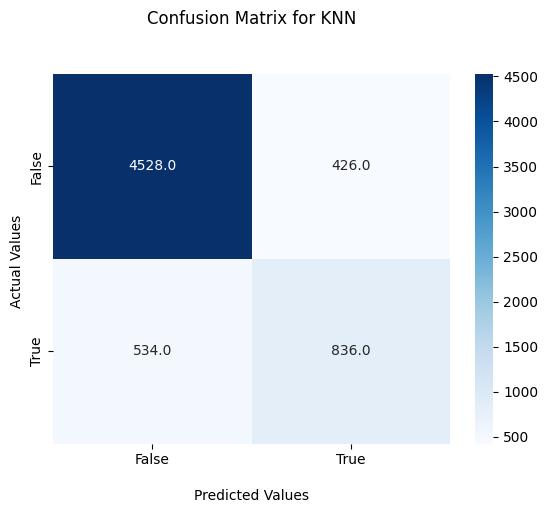

In [266]:
import seaborn as sns
cf_matrix = confusion_matrix(y_test, knn_y_pred)
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for KNN\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

## **2. Logistic Regression**



In [267]:
#Logistic Regression
LR_model= LogisticRegression()
LR_model.fit(X_train,y_train)
LR_y_pred=LR_model.predict(X_test)
print('Logistic Regression\n', classification_report(y_test,LR_y_pred))

Logistic Regression
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      4954
           1       0.51      0.77      0.62      1370

    accuracy                           0.79      6324
   macro avg       0.72      0.79      0.74      6324
weighted avg       0.84      0.79      0.81      6324



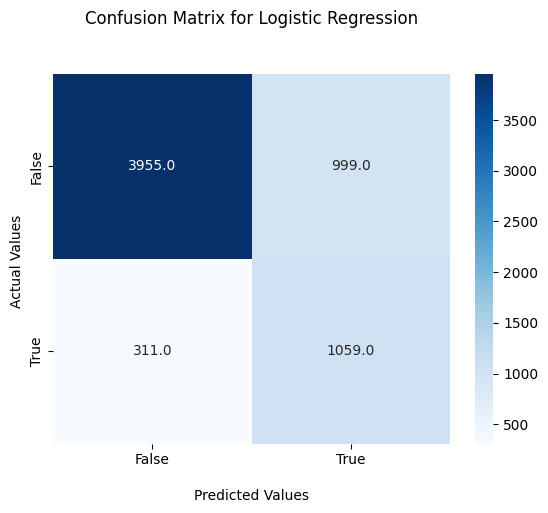

In [268]:
cf_matrix = confusion_matrix(y_test, LR_y_pred)
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for Logistic Regression\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

## **3. Decision Tree**

In [269]:
#Decision Tree
decisiontree_model= DecisionTreeClassifier()
decisiontree_model.fit(X_train,y_train)
decisiontree_y_pred=decisiontree_model.predict(X_test)
print('Decision Tree\n', classification_report(y_test,decisiontree_y_pred))

Decision Tree
               precision    recall  f1-score   support

           0       0.94      0.91      0.92      4954
           1       0.70      0.78      0.74      1370

    accuracy                           0.88      6324
   macro avg       0.82      0.84      0.83      6324
weighted avg       0.89      0.88      0.88      6324



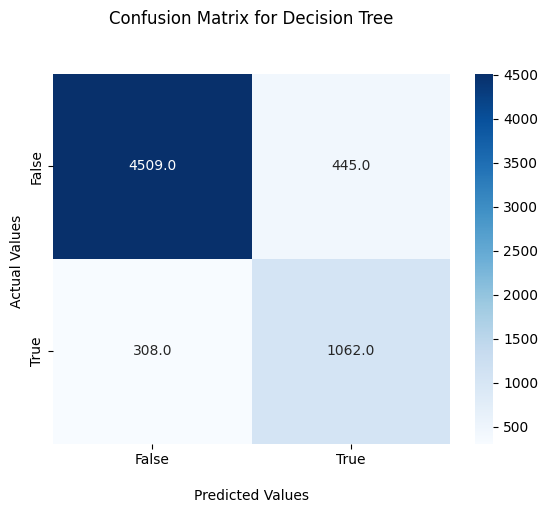

In [270]:
cf_matrix = confusion_matrix(y_test, decisiontree_y_pred)
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for Decision Tree\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

## **4. Random Forest Classifier**

In [271]:
# Random Forest Classifier
forest_model=  RandomForestClassifier()
forest_model.fit(X_train,y_train)
forest_y_pred=forest_model.predict(X_test)
print('Random Forest\n', classification_report(y_test, forest_y_pred))

Random Forest
               precision    recall  f1-score   support

           0       0.93      0.98      0.96      4954
           1       0.92      0.74      0.82      1370

    accuracy                           0.93      6324
   macro avg       0.93      0.86      0.89      6324
weighted avg       0.93      0.93      0.93      6324



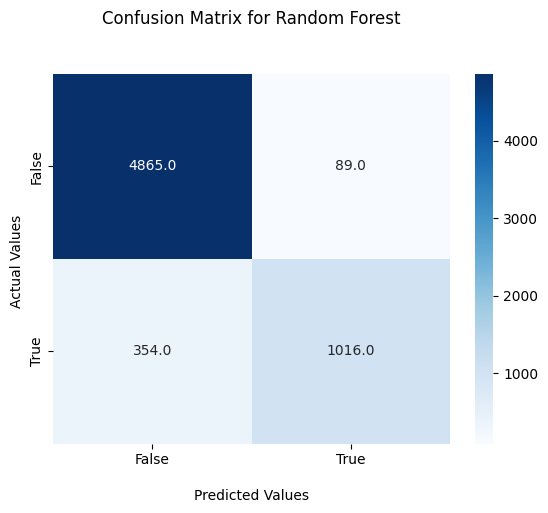

In [272]:
cf_matrix = confusion_matrix(y_test, forest_y_pred.round())
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for Random Forest\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

# **Handling the imperfect dataset**

---



---



In [273]:
y_train.value_counts()

,count
loan_status,
0,19761
1,19761


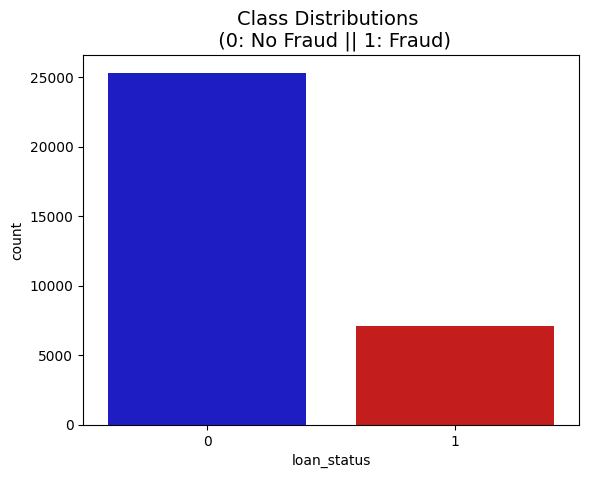

In [274]:

colors = ["#0101DF", "#DF0101"]

sns.countplot(x='loan_status', data=df_loan, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14);
colors = ["#0101DF", "#DF0101"]

## **SMOTE Oversampling**

---



---



SMOTE stands for Synthetic Minority Over-sampling Technique. Unlike Random UnderSampling, SMOTE creates new synthetic points in order to have an equal balance of the classes. This is another alternative for solving the "class imbalance problems".


Understanding SMOTE:


*   Solving the Class Imbalance: SMOTE creates synthetic points from the minority class in order to reach an equal balance between the minority and majority class.
*   Location of the synthetic points: SMOTE picks the distance between the closest neighbors of the minority class, in between these distances it creates synthetic points.

*   Final Effect: More information is retained since we didn't have to delete any rows unlike in random undersampling.
*   Accuracy || Time Tradeoff: Although it is likely that SMOTE will be more accurate than random under-sampling, it is more costly than undersampling methods.

In [275]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=2,)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [276]:
print('The shape of our training data is:', X_train.shape)

The shape of our training data is: (39522, 18)


In [277]:
pd.DataFrame(y_train.value_counts())

,count
loan_status,
0,19761
1,19761


**Therefore the dataset is now balanced and hence we will retrain the model.**

# **K Nearest Neighbors**

In [278]:
#KNN
knn_model= KNeighborsClassifier(n_neighbors=max_k)
knn_model.fit(X_train,y_train)
knn_y_pred=knn_model.predict(X_test)
print('KNN\n', classification_report(y_test,knn_y_pred))

KNN
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      4954
           1       0.66      0.61      0.64      1370

    accuracy                           0.85      6324
   macro avg       0.78      0.76      0.77      6324
weighted avg       0.84      0.85      0.85      6324



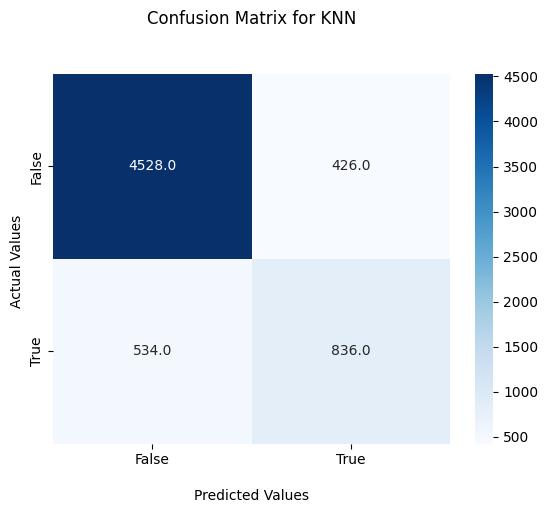

In [279]:
cf_matrix = confusion_matrix(y_test, knn_y_pred)
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for KNN\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

# **Logistic Regression**

In [280]:
#Logistic Regression
LR_model= LogisticRegression()
LR_model.fit(X_train,y_train)
LR_y_pred=LR_model.predict(X_test)
print('Logistic Regression\n', classification_report(y_test,LR_y_pred))

Logistic Regression
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      4954
           1       0.51      0.77      0.62      1370

    accuracy                           0.79      6324
   macro avg       0.72      0.79      0.74      6324
weighted avg       0.84      0.79      0.81      6324



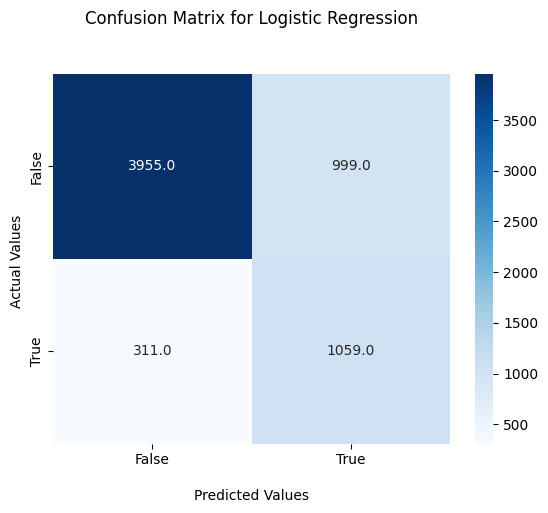

In [281]:
cf_matrix = confusion_matrix(y_test, LR_y_pred)
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for Logistic Regression\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

# **Decision Tree**

In [282]:
#Decision Tree
decisiontree_model= DecisionTreeClassifier()
decisiontree_model.fit(X_train,y_train)
decisiontree_y_pred=decisiontree_model.predict(X_test)
print('Decision Tree\n', classification_report(y_test,decisiontree_y_pred))

Decision Tree
               precision    recall  f1-score   support

           0       0.94      0.91      0.92      4954
           1       0.70      0.78      0.74      1370

    accuracy                           0.88      6324
   macro avg       0.82      0.84      0.83      6324
weighted avg       0.89      0.88      0.88      6324



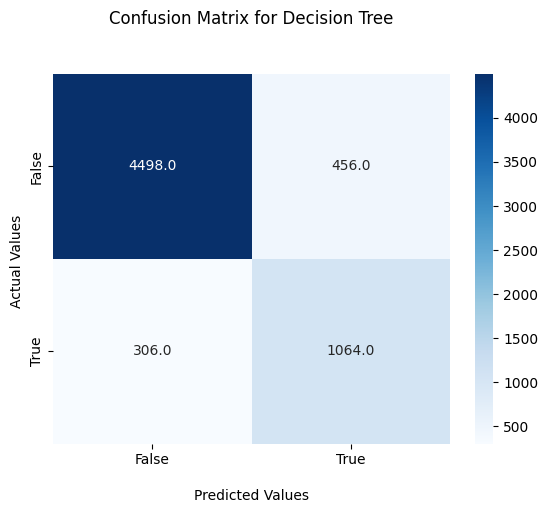

In [283]:
cf_matrix = confusion_matrix(y_test, decisiontree_y_pred)
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for Decision Tree\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

# **Random Forest Classifier**

In [284]:
# Random Forest Classifier
forest_model=  RandomForestClassifier()
forest_model.fit(X_train,y_train)
forest_y_pred=forest_model.predict(X_test)
print('Random Forest\n', classification_report(y_test, forest_y_pred))

Random Forest
               precision    recall  f1-score   support

           0       0.93      0.98      0.96      4954
           1       0.93      0.74      0.83      1370

    accuracy                           0.93      6324
   macro avg       0.93      0.86      0.89      6324
weighted avg       0.93      0.93      0.93      6324



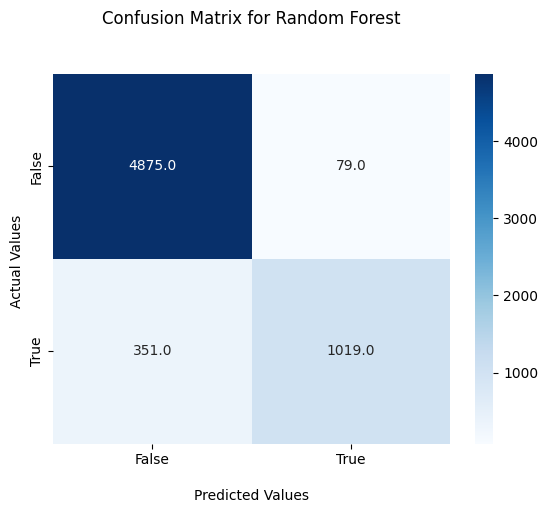

In [285]:
cf_matrix = confusion_matrix(y_test, forest_y_pred.round())
ax = sns.heatmap(cf_matrix, annot=True, fmt=".1f",cmap='Blues')

ax.set_title('Confusion Matrix for Random Forest\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.show()

# XGBoost Classifier

In [286]:
from sklearn.metrics import classification_report
from sklearn.svm import SVC
import xgboost as xgb


xgb_model = xgb.XGBClassifier(
    n_estimators=300,        # number of trees
    learning_rate=0.1,       # step size shrinkage
    max_depth=6,             # tree depth
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    random_state=42,
    use_label_encoder=False, # suppress warning
    eval_metric='logloss'    # evaluation metric
)

xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)

print("XGBoost Classifier\n", classification_report(y_test, xgb_y_pred))




XGBoost Classifier
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      4954
           1       0.96      0.75      0.84      1370

    accuracy                           0.94      6324
   macro avg       0.95      0.87      0.90      6324
weighted avg       0.94      0.94      0.94      6324



[[4910   44]
 [ 348 1022]]


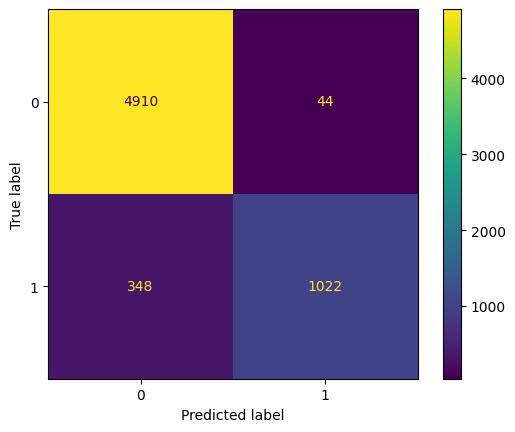

In [287]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_y_pred)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

<h1>LightGBM

In [288]:
# Install LightGBM if needed
!pip install lightgbm

In [289]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [290]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19761, number of negative: 19761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3066
[LightGBM] [Info] Number of data points in the train set: 39522, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
               objective='binary', random_state=42, subsample=0.8)

In [291]:
y_pred_lg = lgbm_model.predict(X_test)

In [292]:
y_prob_lg = lgbm_model.predict_proba(X_test)[:, 1]

In [293]:

print("\nClassification Report LightGBM:")
print(classification_report(y_test, y_pred_lg))



Classification Report LightGBM:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4954
           1       0.97      0.74      0.84      1370

    accuracy                           0.94      6324
   macro avg       0.95      0.87      0.90      6324
weighted avg       0.94      0.94      0.94      6324



Random Forest ROC-AUC: 0.9287285361088436
XGBoost ROC-AUC: 0.9484484999219094
LightGBM ROC-AUC: 0.9470860382673885


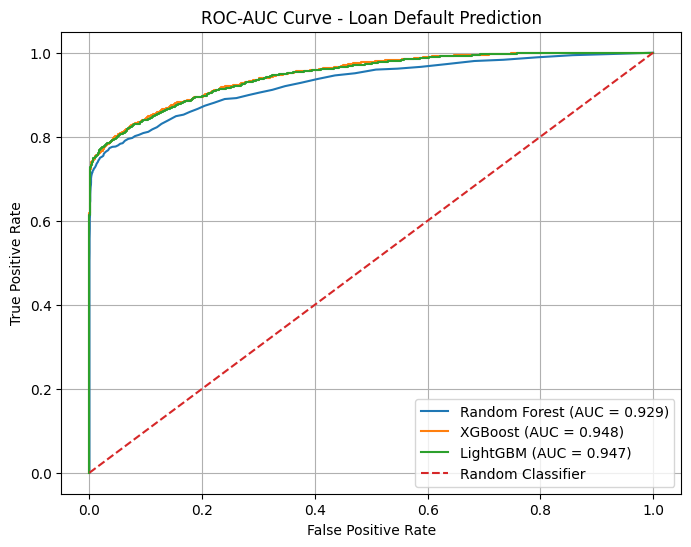

In [294]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of class 1 (Default)
rf_prob = forest_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]   # LightGBM

# ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_prob)

# AUC
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)
lgbm_auc = roc_auc_score(y_test, lgbm_prob)

# Print AUC
print("Random Forest ROC-AUC:", rf_auc)
print("XGBoost ROC-AUC:", xgb_auc)
print("LightGBM ROC-AUC:", lgbm_auc)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    xgb_fpr, xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    lgbm_fpr, lgbm_tpr,
    label=f"LightGBM (AUC = {lgbm_auc:.3f})"
)

# Random classifier
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - Loan Default Prediction")
plt.legend()
plt.grid()

plt.show()

In [295]:

print("\nClassification Report LightGBM:")
print(classification_report(y_test, y_pred_lg))
print("\nClassification Report Random Forest:")
print(classification_report(y_test, forest_y_pred))
print("\nClassification Report Random Forest:")
print(classification_report(y_test, xgb_y_pred))


Classification Report LightGBM:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4954
           1       0.97      0.74      0.84      1370

    accuracy                           0.94      6324
   macro avg       0.95      0.87      0.90      6324
weighted avg       0.94      0.94      0.94      6324


Classification Report Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      4954
           1       0.93      0.74      0.83      1370

    accuracy                           0.93      6324
   macro avg       0.93      0.86      0.89      6324
weighted avg       0.93      0.93      0.93      6324


Classification Report Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4954
           1       0.96      0.75      0.84      1370

    accuracy                           0.94      6324
   macro avg       

<h1>Optuna

In [296]:
!pip install optuna

In [297]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [298]:
from xgboost import XGBClassifier
def xgb_objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.2, log=True
        ),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int(
            'min_child_weight', 1, 10
        ),
        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0
        ),
        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0
        ),
        'gamma': trial.suggest_float(
            'gamma', 0, 5
        ),
        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-8, 10, log=True
        ),
        'reg_lambda': trial.suggest_float(
            'reg_lambda', 1e-8, 10, log=True
        )
    }

    model = XGBClassifier(
        **params,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

In [299]:

xgb_study = optuna.create_study(direction='maximize')

xgb_study.optimize(
    xgb_objective,
    n_trials=20
)

[I 2026-09-06 13:29:41,643] A new study created in memory with name: no-name-f5014829-6c09-4d18-baae-8280349f1d15
[I 2026-09-06 13:30:28,816] Trial 0 finished with value: 0.9867878905373264 and parameters: {'n_estimators': 632, 'learning_rate': 0.03235208162773598, 'max_depth': 9, 'min_child_weight': 4, 'subsample': 0.6962511361685852, 'colsample_bytree': 0.8648014476250523, 'gamma': 1.1673946475867558, 'reg_alpha': 5.698323098105057e-06, 'reg_lambda': 0.0021201980697312375}. Best is trial 0 with value: 0.9867878905373264.
[I 2026-09-06 13:30:38,154] Trial 1 finished with value: 0.9860444280884046 and parameters: {'n_estimators': 362, 'learning_rate': 0.18509772275089795, 'max_depth': 5, 'min_child_weight': 9, 'subsample': 0.9017011650264211, 'colsample_bytree': 0.8886915147214118, 'gamma': 0.898063238024111, 'reg_alpha': 3.4632596886155204e-05, 'reg_lambda': 0.35872259694156927}. Best is trial 0 with value: 0.9867878905373264.
[I 2026-09-06 13:30:45,559] Trial 2 finished with value: 0

In [300]:
from sklearn.metrics import roc_auc_score
best_xgb = XGBClassifier(
    **xgb_study.best_params,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

xgb_test_auc = roc_auc_score(y_test, xgb_proba)

print("XGBoost Test ROC-AUC:", xgb_test_auc)

XGBoost Test ROC-AUC: 0.9483701145428453


In [301]:
# Final predictions
xgb_y_pred = best_xgb.predict(X_test)

# Classification report
print("Final XGBoost Classification Report:")
print(classification_report(y_test, xgb_y_pred))

Final XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4954
           1       0.97      0.75      0.84      1370

    accuracy                           0.94      6324
   macro avg       0.95      0.87      0.90      6324
weighted avg       0.94      0.94      0.94      6324



# **Conclusion:**

---



---



XGBoost (Optuna-tuned) was the best model, with a test ROC-AUC of 0.949 and F1-score of 0.85 on defaults — slightly ahead of Random Forest (0.927 ROC-AUC). All models showed high precision (0.92–0.97) but lower recall (~0.74–0.76) on defaults, meaning they miss about a quarter of actual defaulters. Since missed defaults are costlier than false alarms for a lender, the decision threshold would likely need lowering below 0.5 before deployment. SMOTE and gradient boosting helped recall on the minority class. XGBoost was saved as the final model.

In [302]:
feature_columns = X.columns.tolist()

In [303]:
import joblib
joblib.dump(best_xgb, "model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(imputer1, "imputerknn.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Model trained successfully!")
print("Model and preprocessing objects saved.")

Model trained successfully!
Model and preprocessing objects saved.


In [304]:
import numpy as np
import shap

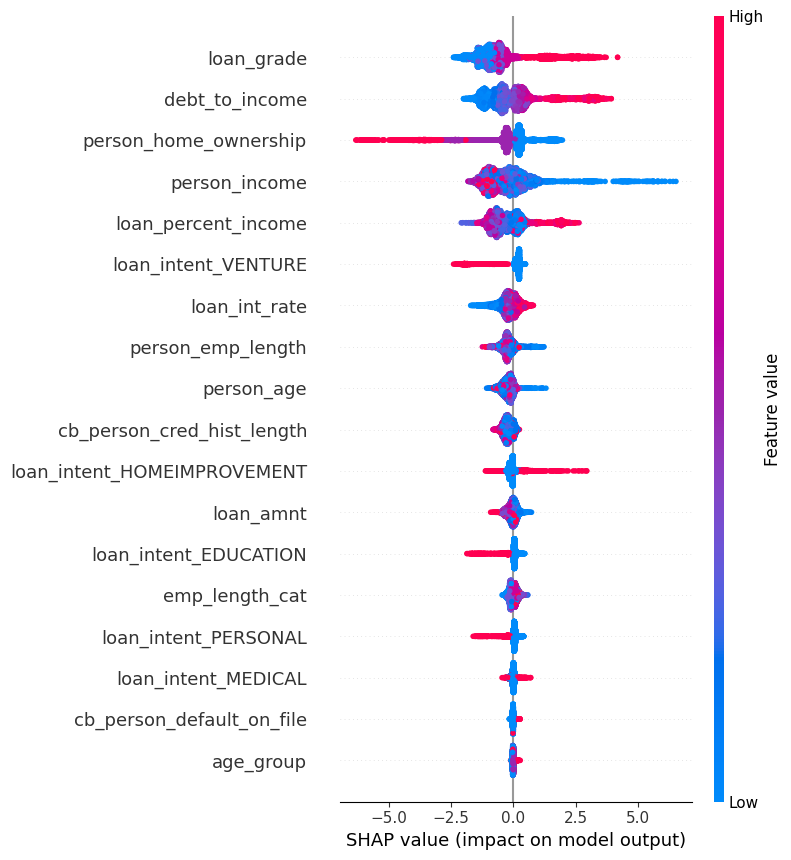

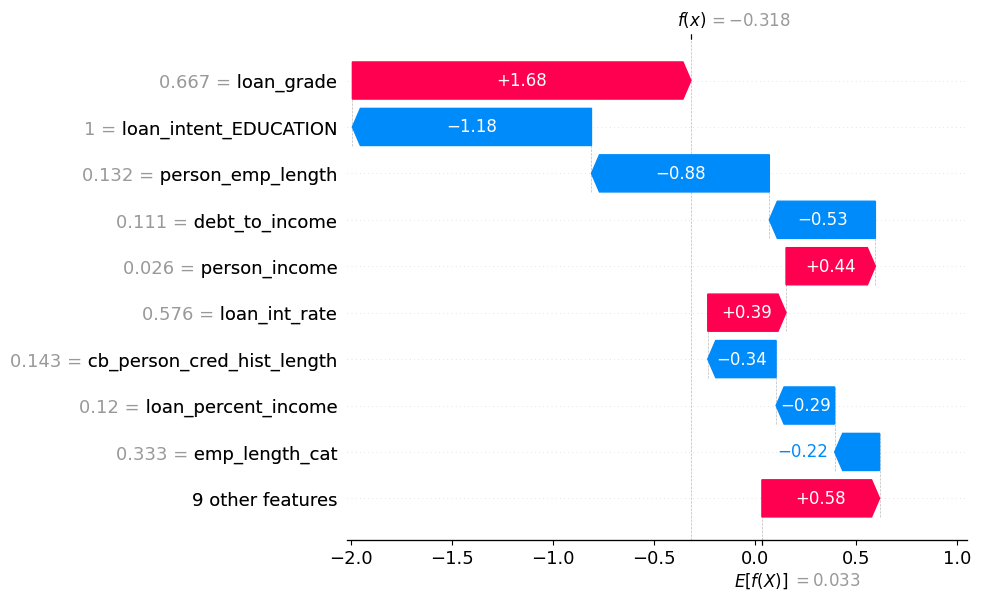

In [305]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# Optional: Visualize global importance (manual inspection)
shap.summary_plot(shap_values, X_test)

# Optional: Visualize one prediction (manual inspection)
shap.plots.waterfall(shap_values[0])

In [ ]:

joblib.dump(explainer, "shap_explainer.pkl")

['shap_explainer.pkl']